# Análise Exploratória de Dados (EDA)
## Desafio Data Science — Previsão de Preços de Imóveis em Seattle

Este notebook cobre:
- Entendimento das variáveis e qualidade dos dados
- Merge dos dados físicos com dados demográficos por zipcode
- Distribuição de preços, correlações e outliers
- Padrões geográficos, temporais e socioeconômicos


In [7]:
# =============================================================================
# DESAFIO DATA SCIENCE — Seattle House Prices
# Script 01: Análise Exploratória de Dados (EDA)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import missingno as msno

warnings.filterwarnings("ignore")

try:
    BASE = os.path.join(os.path.dirname(os.path.abspath(__file__)), "..")
except NameError:
    BASE = os.path.join(os.getcwd(), "..")
DATA_DIR = os.path.join(BASE, "data")
OUT_DIR  = os.path.join(BASE, "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

In [9]:
# 1. CARREGAMENTO DOS DADOS 
house  = pd.read_csv(os.path.join(DATA_DIR, "kc_house_data.csv"))
demo   = pd.read_csv(os.path.join(DATA_DIR, "zipcode_demographics.csv"))
future = pd.read_csv(os.path.join(DATA_DIR, "future_unseen_examples.csv"))

print("=== kc_house_data ===")
print(f"Shape: {house.shape}")
print(house.dtypes.to_string())
print(house.describe().round(2).to_string())

print("\n=== zipcode_demographics ===")
print(f"Shape: {demo.shape}")
print(demo.dtypes.to_string())

print("\n=== future_unseen_examples ===")
print(f"Shape: {future.shape}")
print(future.dtypes.to_string())

=== kc_house_data ===
Shape: (21613, 21)
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
                 id       price  bedrooms  bathrooms  sqft_living    sqft_lot    floors  waterfront      view  condition     grade  sqft_above  sqft_basement  yr_built  yr_renovated   zipcode       lat      long  sqft_living15  sqft_lot15
count  2.161300e+04    21613.00  21613.00   21613.00     21613.00    21613.00  21613.00    21613.00  21613.00   21613.00  21613.00    21613.00       21613.00  21613.00      21613.00  21613.00  21

In [11]:
# VERIFIACANDO O TAMANHO DO DATASET 
house.shape

(21613, 21)

In [13]:
# VERIFIACANDO O TAMANHO DO DATASET 
future.shape

(100, 18)

In [15]:
# VENDO O DATASET 
future.shape

(100, 18)

In [17]:
# VENDO OS DADOS 
house.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [19]:
# VENDO OS DADOS 
demo.head(10)

,ppltn_qty,urbn_ppltn_qty,sbrbn_ppltn_qty,farm_ppltn_qty,non_farm_qty,medn_hshld_incm_amt,medn_incm_per_prsn_amt,hous_val_amt,edctn_less_than_9_qty,edctn_9_12_qty,...,per_farm,per_non_farm,per_less_than_9,per_9_to_12,per_hsd,per_some_clg,per_assoc,per_bchlr,per_prfsnl,zipcode
0,38249.0,37394.0,0.0,0.0,855.0,66051.0,25219.0,192000.0,437.0,2301.0,...,0.0,2.0,1.0,6.0,18.0,20.0,5.0,12.0,4.0,98042
1,22036.0,22036.0,0.0,0.0,0.0,91904.0,53799.0,573900.0,149.0,404.0,...,0.0,0.0,0.0,1.0,6.0,12.0,3.0,27.0,22.0,98040
2,18194.0,18194.0,0.0,0.0,0.0,61813.0,31765.0,246600.0,269.0,905.0,...,0.0,0.0,1.0,4.0,13.0,20.0,6.0,19.0,9.0,98028
3,21956.0,21956.0,0.0,0.0,0.0,47461.0,22158.0,175400.0,925.0,1773.0,...,0.0,0.0,4.0,8.0,20.0,21.0,5.0,12.0,4.0,98178
4,22814.0,22814.0,0.0,0.0,0.0,48606.0,28398.0,252600.0,599.0,1148.0,...,0.0,0.0,2.0,5.0,13.0,17.0,5.0,23.0,12.0,98007
5,9533.0,9533.0,0.0,0.0,0.0,37411.0,22044.0,167200.0,364.0,925.0,...,0.0,0.0,3.0,9.0,21.0,24.0,6.0,10.0,2.0,98148
6,43121.0,43121.0,0.0,0.0,0.0,41743.0,23137.0,204200.0,1254.0,3055.0,...,0.0,0.0,2.0,7.0,17.0,22.0,6.0,17.0,7.0,98133
7,19435.0,19435.0,0.0,0.0,0.0,47519.0,25844.0,200000.0,964.0,1516.0,...,0.0,0.0,4.0,7.0,16.0,19.0,5.0,16.0,7.0,98126
8,25495.0,25245.0,0.0,0.0,250.0,60534.0,24011.0,168400.0,475.0,1828.0,...,0.0,0.0,1.0,7.0,20.0,20.0,6.0,10.0,3.0,98001
9,43263.0,43263.0,0.0,0.0,0.0,58475.0,34026.0,282800.0,370.0,1090.0,...,0.0,0.0,0.0,2.0,8.0,15.0,4.0,30.0,20.0,98115


In [21]:
# VENDO OS DADOS 
future.head(10)

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,4,1.00,1680,5043,1.5,0,0,4,6,1680,0,1911,0,98118,47.5354,-122.273,1560,5765
1,3,2.50,2220,6380,1.5,0,0,4,8,1660,560,1931,0,98115,47.6974,-122.313,950,6380
2,3,2.25,1630,10962,1.0,0,0,4,8,1100,530,1977,0,98030,47.3801,-122.166,1830,8470
3,5,2.50,1710,9720,2.0,0,0,4,8,1710,0,1974,0,98005,47.5903,-122.157,2270,9672
4,2,1.00,850,6370,1.0,0,0,3,6,850,0,1951,0,98126,47.5198,-122.373,850,5170
5,4,2.75,2630,4501,2.0,0,0,3,8,2630,0,2015,0,98028,47.7748,-122.244,2380,4599
6,4,1.75,2290,7380,1.0,0,0,3,7,1390,900,1963,0,98178,47.5034,-122.245,1170,7381
7,4,2.00,1730,9139,2.0,0,0,3,8,1730,0,1957,0,98125,47.7181,-122.316,1410,7311
8,3,1.75,2190,8500,1.0,0,0,4,9,2190,0,1957,0,98112,47.6400,-122.285,2850,8868
9,3,1.75,1850,22767,1.5,0,4,5,6,1850,0,1908,0,98074,47.6144,-122.067,2700,17906


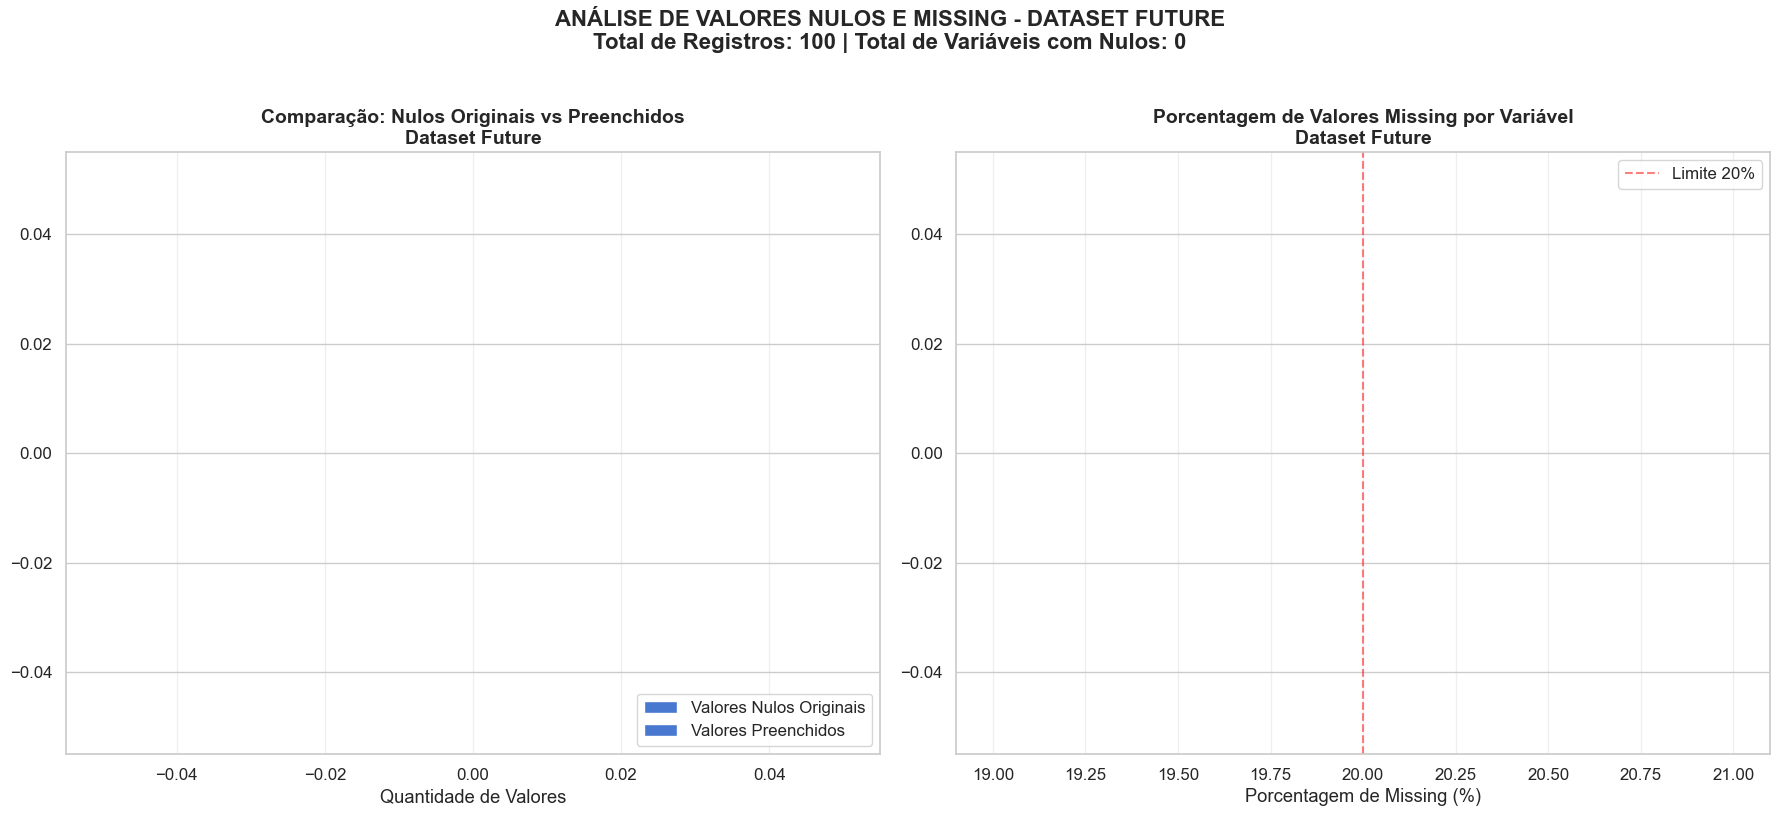


RESUMO DA ANÁLISE - DATASET FUTURE
Total de registros no dataset: 100
Total de variáveis: 18
Variáveis com valores nulos: 0
Total de valores nulos: 0
Percentual total de nulos: 0.00%

Variáveis com mais de 20% de missing:
Empty DataFrame
Columns: [Variável, Missing (%)]
Index: []


In [23]:
# ANALISANDO NULOS, MISSING FUTURE
df = future.copy()

# Criar uma cópia com valores preenchidos (escolha um método)
df_preenchido = df.copy()

# Preencher valores nulos (ajuste o método conforme necessário)
# Para colunas numéricas: preencher com média
colunas_numericas = df_preenchido.select_dtypes(include=[np.number]).columns
for col in colunas_numericas:
    df_preenchido[col] = df_preenchido[col].fillna(df_preenchido[col].mean())

# Para colunas categóricas: preencher com moda
colunas_categoricas = df_preenchido.select_dtypes(include=['object']).columns
for col in colunas_categoricas:
    df_preenchido[col] = df_preenchido[col].fillna(df_preenchido[col].mode()[0] if not df_preenchido[col].mode().empty else 'Desconhecido')

# Criar DataFrame com contagens
comparacao = pd.DataFrame({
    'Variável': df.columns,
    'Valores Nulos': df.isnull().sum().values,
    'Missing (%)': (df.isnull().sum() / len(df) * 100).values,
    'Valores Preenchidos': df_preenchido.isnull().sum().values,
    'Total Original': [len(df)] * len(df.columns),
    'Total Após Preenchimento': [len(df_preenchido)] * len(df.columns)
})

# Filtrar apenas variáveis que tinham nulos
comparacao = comparacao[comparacao['Valores Nulos'] > 0].sort_values('Valores Nulos', ascending=False)

# VISUALIZAÇÃO ÚNICA
fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(comparacao) * 0.4)))

# GRÁFICO 1: Barras - Nulos vs Preenchidos
x = range(len(comparacao))
width = 0.35

bars1 = axes[0].barh([v[:20] for v in comparacao['Variável']], comparacao['Valores Nulos'], 
                     height=width, label='Valores Nulos Originais', color='red', alpha=0.7)
bars2 = axes[0].barh([v[:20] for v in comparacao['Variável']], comparacao['Valores Preenchidos'], 
                     height=width, left=comparacao['Valores Nulos'], 
                     label='Valores Preenchidos', color='green', alpha=0.7)

axes[0].set_xlabel('Quantidade de Valores')
axes[0].set_title('Comparação: Nulos Originais vs Preenchidos\nDataset Future', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3, axis='x')

# Adicionar valores nas barras
for i, (nulos, preenchidos) in enumerate(zip(comparacao['Valores Nulos'], comparacao['Valores Preenchidos'])):
    if nulos > 0:
        axes[0].text(nulos/2, i, f'{int(nulos)}', ha='center', va='center', fontweight='bold')
    if preenchidos > 0:
        axes[0].text(nulos + preenchidos/2, i, f'{int(preenchidos)}', ha='center', va='center', fontweight='bold')

# GRÁFICO 2: Porcentagem de Missing
bars3 = axes[1].barh([v[:20] for v in comparacao['Variável']], comparacao['Missing (%)'], 
                     color='orange', alpha=0.8, edgecolor='darkorange', linewidth=1)
axes[1].set_xlabel('Porcentagem de Missing (%)')
axes[1].set_title('Porcentagem de Valores Missing por Variável\nDataset Future', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Adicionar valores nas barras
for i, pct in enumerate(comparacao['Missing (%)']):
    axes[1].text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontweight='bold')

# Linha de referência de 20%
axes[1].axvline(x=20, color='red', linestyle='--', alpha=0.5, label='Limite 20%')
axes[1].legend()

plt.suptitle(f'ANÁLISE DE VALORES NULOS E MISSING - DATASET FUTURE\nTotal de Registros: {len(df)} | Total de Variáveis com Nulos: {len(comparacao)}', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Print resumo
print("\n" + "="*80)
print("RESUMO DA ANÁLISE - DATASET FUTURE")
print("="*80)
print(f"Total de registros no dataset: {len(df)}")
print(f"Total de variáveis: {len(df.columns)}")
print(f"Variáveis com valores nulos: {len(comparacao)}")
print(f"Total de valores nulos: {df.isnull().sum().sum()}")
print(f"Percentual total de nulos: {(df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.2f}%")
print("\nVariáveis com mais de 20% de missing:")
print(comparacao[comparacao['Missing (%)'] > 20][['Variável', 'Missing (%)']].to_string(index=False))

In [25]:
# 2. LIMPEZA E PREPARAÇÃO
house["date"]       = pd.to_datetime(house["date"], format="%Y%m%dT%H%M%S")
house["year_sold"]  = house["date"].dt.year
house["month_sold"] = house["date"].dt.month
house_clean = house.drop(columns=["id", "date"])

print("\n--- Qualidade dos dados ---")
print("Nulos kc_house_data:", house_clean.isnull().sum().sum())
print("Nulos zipcode_demographics:", demo.isnull().sum().sum())
print("Duplicatas kc_house_data:", house_clean.duplicated().sum())


--- Qualidade dos dados ---
Nulos kc_house_data: 0
Nulos zipcode_demographics: 0
Duplicatas kc_house_data: 2


In [27]:
# 3. MERGE COM DEMOGRAPHICS
demo["zipcode"]       = demo["zipcode"].astype(int)
house_clean["zipcode"] = house_clean["zipcode"].astype(int)
df = house_clean.merge(demo, on="zipcode", how="left")
print(f"\nShape após merge: {df.shape}")
print("Nulos após merge:", df.isnull().sum().sum())
df.to_csv(os.path.join(OUT_DIR, "merged_dataset.csv"), index=False)

# Estatísticas descritivas
desc = df[["price","sqft_living","bedrooms","bathrooms","grade","yr_built",
           "medn_hshld_incm_amt","hous_val_amt"]].describe().round(2)
print("\nEstatísticas descritivas:\n", desc.to_string())
desc.to_csv(os.path.join(OUT_DIR, "descriptive_stats.csv"))


Shape após merge: (21613, 47)
Nulos após merge: 0

Estatísticas descritivas:
             price  sqft_living  bedrooms  bathrooms     grade  yr_built  medn_hshld_incm_amt  hous_val_amt
count    21613.00     21613.00  21613.00   21613.00  21613.00  21613.00             21613.00      21613.00
mean    540088.14      2079.90      3.37       2.11      7.66   1971.01             57939.93     253485.24
std     367127.20       918.44      0.93       0.77      1.18     29.37             13696.57      82711.33
min      75000.00       290.00      0.00       0.00      1.00   1900.00             32085.00     141500.00
25%     321950.00      1427.00      3.00       1.75      7.00   1951.00             47519.00     196900.00
50%     450000.00      1910.00      3.00       2.25      7.00   1975.00             57411.00     239850.00
75%     645000.00      2550.00      4.00       2.50      8.00   1997.00             65514.00     282800.00
max    7700000.00     13540.00     33.00       8.00     13.00   2

In [29]:
# 4. DISTRIBUIÇÃO DO PREÇO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price"] / 1e6, bins=80, color="#4C72B0", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Preço (milhões USD)")
axes[0].set_ylabel("Quantidade de imóveis")
axes[0].set_title("Distribuição do Preço")
axes[0].axvline(df["price"].median()/1e6, color="red", linestyle="--",
                label=f'Mediana: ${df["price"].median()/1e6:.2f}M')
axes[0].legend()

axes[1].hist(np.log1p(df["price"]), bins=80, color="#55A868", edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("log(Preço + 1)")
axes[1].set_ylabel("Quantidade de imóveis")
axes[1].set_title("Distribuição do Preço (escala log)")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "01_price_distribution.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Salvo: 01_price_distribution.png")

Salvo: 01_price_distribution.png


In [31]:
# 5. CORRELAÇÃO COM PREÇO
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_price = df[numeric_cols].corr()["price"].drop("price").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["#4C72B0" if v > 0 else "#C44E52" for v in corr_price.values]
ax.barh(corr_price.index, corr_price.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlação de Pearson com Preço")
ax.set_title("Correlação das Features com o Preço")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02_correlation_price.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Salvo: 02_correlation_price.png")

Salvo: 02_correlation_price.png


In [33]:
# 6. HEATMAP DAS PRINCIPAIS FEATURES
top_features = ["price","sqft_living","grade","sqft_above","sqft_living15",
                "bathrooms","bedrooms","floors","yr_built","waterfront",
                "medn_hshld_incm_amt","hous_val_amt","medn_incm_per_prsn_amt"]
top_features = [c for c in top_features if c in df.columns]

fig, ax = plt.subplots(figsize=(13, 10))
corr_matrix = df[top_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, linewidths=0.5, annot_kws={"size": 8})
ax.set_title("Heatmap de Correlação — Principais Features")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03_heatmap.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Salvo: 03_heatmap.png")

Salvo: 03_heatmap.png


In [35]:
# 7. SCATTER: sqft_living e grade vs preço
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df.sample(3000, random_state=42)

axes[0].scatter(sample["sqft_living"], sample["price"]/1e6, alpha=0.3, s=10, color="#4C72B0")
axes[0].set_xlabel("sqft_living (área interna)")
axes[0].set_ylabel("Preço (milhões USD)")
axes[0].set_title("Área Interna vs Preço")

axes[1].scatter(sample["grade"], sample["price"]/1e6, alpha=0.3, s=10, color="#DD8452")
axes[1].set_xlabel("Grade (qualidade da construção)")
axes[1].set_ylabel("Preço (milhões USD)")
axes[1].set_title("Grade vs Preço")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "04_scatter_key_features.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Salvo: 04_scatter_key_features.png")

Salvo: 04_scatter_key_features.png


In [37]:
# 8. WATERFRONT e VIEW
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

wf_medians = df.groupby("waterfront")["price"].median() / 1e6
axes[0].bar(["Sem Vista para Água", "Com Vista para Água"], wf_medians.values,
            color=["#4C72B0", "#55A868"])
axes[0].set_ylabel("Mediana do Preço (milhões USD)")
axes[0].set_title("Impacto da Vista para Água no Preço")
for i, v in enumerate(wf_medians.values):
    axes[0].text(i, v + 0.02, f"${v:.2f}M", ha="center", fontweight="bold")

view_medians = df.groupby("view")["price"].median() / 1e6
axes[1].bar(view_medians.index.astype(str), view_medians.values,
            color=sns.color_palette("Blues_d", 5))
axes[1].set_xlabel("Score de Vista (0-4)")
axes[1].set_ylabel("Mediana do Preço (milhões USD)")
axes[1].set_title("Score de Vista vs Preço")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "05_waterfront_view.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Salvo: 05_waterfront_view.png")

Salvo: 05_waterfront_view.png


In [39]:
# 9. BOXPLOT PREÇO POR GRADE
fig, ax = plt.subplots(figsize=(14, 6))
grades = sorted(df["grade"].unique())
data_by_grade = [df[df["grade"] == g]["price"].values / 1e6 for g in grades]
bp = ax.boxplot(data_by_grade, labels=grades, patch_artist=True, showfliers=True,
                flierprops=dict(marker="o", markersize=2, alpha=0.3))
palette = sns.color_palette("RdYlGn", len(grades))
for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
ax.set_xlabel("Grade (Qualidade da Construção)")
ax.set_ylabel("Preço (milhões USD)")
ax.set_title("Distribuição do Preço por Grade — Identificação de Outliers")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "06_boxplot_grade.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Salvo: 06_boxplot_grade.png")

Salvo: 06_boxplot_grade.png


In [41]:
# 10. PREÇO MEDIANO POR ZIPCODE (TOP 20)
zip_price = df.groupby("zipcode")["price"].median().sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(13, 6))
zip_price.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Zipcode")
ax.set_ylabel("Mediana do Preço (USD)")
ax.set_title("Top 20 Zipcodes por Mediana de Preço")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "07_price_by_zipcode.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Salvo: 07_price_by_zipcode.png")

Salvo: 07_price_by_zipcode.png


In [43]:
# 11. RENDA vs PREÇO POR ZIPCODE
zip_agg = df.groupby("zipcode").agg(
    median_price=("price", "median"),
    median_income=("medn_hshld_incm_amt", "median"),
    count=("price", "count")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(zip_agg["median_income"]/1e3, zip_agg["median_price"]/1e6,
                s=zip_agg["count"]*0.5, alpha=0.6, c=zip_agg["median_price"],
                cmap="RdYlGn", edgecolors="white", linewidth=0.4)
plt.colorbar(sc, ax=ax, label="Mediana Preço (USD)")
ax.set_xlabel("Renda Mediana Domiciliar (mil USD)")
ax.set_ylabel("Mediana do Preço (milhões USD)")
ax.set_title("Renda Domiciliar vs Preço por Zipcode\n(tamanho = nº de imóveis)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "08_income_vs_price.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Salvo: 08_income_vs_price.png")

Salvo: 08_income_vs_price.png


In [45]:
# 12. EVOLUÇÃO TEMPORAL
monthly = df.groupby(["year_sold","month_sold"])["price"].median().reset_index()
monthly["period"] = pd.to_datetime(
    monthly[["year_sold","month_sold"]].rename(
        columns={"year_sold":"year","month_sold":"month"}).assign(day=1))
monthly = monthly.sort_values("period")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["period"], monthly["price"]/1e6, marker="o", linewidth=2, color="#4C72B0")
ax.fill_between(monthly["period"], monthly["price"]/1e6, alpha=0.15, color="#4C72B0")
ax.set_xlabel("Período")
ax.set_ylabel("Mediana do Preço (milhões USD)")
ax.set_title("Evolução Temporal da Mediana de Preço")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_price_over_time.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Salvo: 09_price_over_time.png")

Salvo: 09_price_over_time.png


In [47]:
# 13. EDUCAÇÃO vs PREÇO
edu_corr = df[["per_bchlr","per_prfsnl","per_hsd","per_less_than_9","price"]].corr()["price"].drop("price")
labels = ["% Bacharelado","% Pós-Graduação","% Ensino Médio","% < 9 anos escola"]
colors = ["#55A868" if v > 0 else "#C44E52" for v in edu_corr.values]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(labels, edu_corr.values, color=colors)
ax.set_ylabel("Correlação com Preço")
ax.set_title("Nível Educacional do Zipcode vs Preço do Imóvel")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "10_education_vs_price.png"), dpi=150, bbox_inches="tight")
plt.close()
print("Salvo: 10_education_vs_price.png")

print("\n=== EDA CONCLUIDA — todos os graficos salvos em /outputs ===")

Salvo: 10_education_vs_price.png

=== EDA CONCLUIDA — todos os graficos salvos em /outputs ===
